In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = "/content/drive/MyDrive/data"
imagewidth = 224
imageheight = 224
batchsize = 32
seed = 42

In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
    data,
    validation_split=0.2,
    subset="training",
    image_size=(imagewidth, imageheight),
    batch_size=batchsize,
    seed=seed
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [5]:
validationdata = tf.keras.utils.image_dataset_from_directory(
    data,
    validation_split=0.2,
    subset="validation",
    image_size=(imagewidth, imageheight),
    batch_size=batchsize,
    seed=seed
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [6]:
class_names = train_data.class_names
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Class Names: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
Number of Classes: 6


# Base Model - CNN2d

In [7]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(imagewidth, imageheight, 3)))

# Convolution layer 1:
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Convolution layer 2:
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Convolution layer 3:
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Flattening layer:
model.add(tf.keras.layers.Flatten())

# Fully Connected layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
epoch = 10
history = model.fit(
    train_data,
    validation_data=validationdata,
    epochs=epoch
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 159s 7s/step - accuracy: 0.2684 - loss: 2.3286 - val_accuracy: 0.1864 - val_loss: 1.9228
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 596ms/step - accuracy: 0.2825 - loss: 1.6634 - val_accuracy: 0.3898 - val_loss: 1.5243
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 552ms/step - accuracy: 0.4506 - loss: 1.4227 - val_accuracy: 0.3051 - val_loss: 1.6423
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 496ms/step - accuracy: 0.5438 - loss: 1.2809 - val_accuracy: 0.5311 - val_loss: 1.1992
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 555ms/step - accuracy: 0.6257 - loss: 1.0399 - val_accuracy: 0.4972 - val_loss: 1.3799
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 558ms/step - accuracy: 0.6540 - loss: 0.9288 - val_accuracy: 0.6158 - val_loss: 1.1600
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 555ms/step - accuracy: 0.8249 - loss: 0.5751 - val_accuracy: 0.5650 - val_loss: 1.5057
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 564ms/step - accuracy: 0.8785 - loss: 0.3706 - val_accura

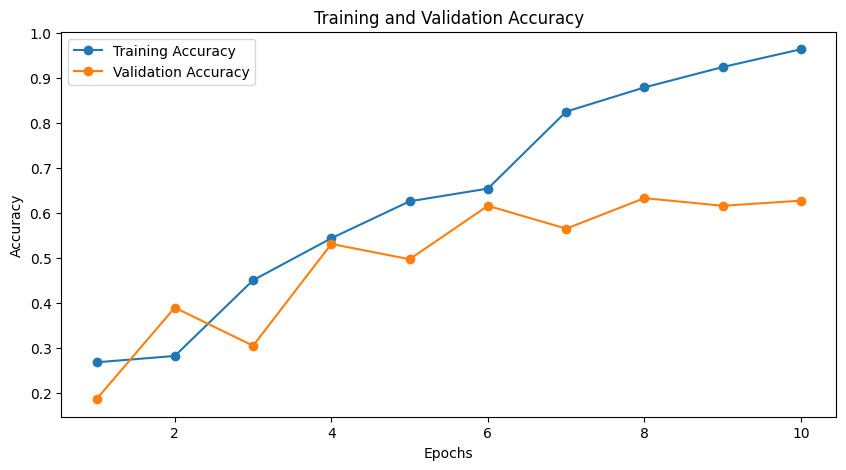

In [11]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, epoch + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
epoch = 20
history = model.fit(
    train_data,
    validation_data=validationdata,
    epochs=epoch
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 543ms/step - accuracy: 0.9732 - loss: 0.0852 - val_accuracy: 0.6723 - val_loss: 1.4829
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 542ms/step - accuracy: 0.9873 - loss: 0.0509 - val_accuracy: 0.6667 - val_loss: 1.6805
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 566ms/step - accuracy: 0.9944 - loss: 0.0397 - val_accuracy: 0.6554 - val_loss: 1.7650
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 562ms/step - accuracy: 0.9929 - loss: 0.0391 - val_accuracy: 0.6780 - val_loss: 1.5730
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 506ms/step - accuracy: 0.9958 - loss: 0.0302 - val_accuracy: 0.6893 - val_loss: 1.6767
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 534ms/step - accuracy: 0.9972 - loss: 0.0221 - val_accuracy: 0.6723 - val_loss: 1.7121
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 515ms/step - accuracy: 0.9944 - loss: 0.0424 - val_accuracy: 0.6271 - val_loss: 1.6816
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 563ms/step - accuracy: 0.9944 - loss: 0.0276 - val_accu

# Solving Overfitting problem

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

In [14]:
from tensorflow.keras.callbacks import LearningRateScheduler

def schedular(epoch, lr):
  if epoch > 5:
    return lr*0.1
  return lr

lr_scheduler = LearningRateScheduler(schedular)

In [15]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(imagewidth, imageheight, 3)))

# Convolution layer 1:
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer 2:
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer 3:
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Dropout(0.3))

# Flattening layer:
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

# Fully Connected layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [16]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [17]:
epoch = 10
history = model.fit(
    train_data,
    validation_data=validationdata,
    epochs=epoch
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 749ms/step - accuracy: 0.3799 - loss: 19.3124 - val_accuracy: 0.1695 - val_loss: 8.2316
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 556ms/step - accuracy: 0.5071 - loss: 1.6688 - val_accuracy: 0.1130 - val_loss: 80.2267
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 475ms/step - accuracy: 0.5650 - loss: 1.1460 - val_accuracy: 0.0960 - val_loss: 141.6271
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 553ms/step - accuracy: 0.6497 - loss: 0.9589 - val_accuracy: 0.0904 - val_loss: 154.2536
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 560ms/step - accuracy: 0.7316 - loss: 0.7770 - val_accuracy: 0.0904 - val_loss: 133.6319
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 501ms/step - accuracy: 0.7952 - loss: 0.6332 - val_accuracy: 0.0904 - val_loss: 93.7578
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 583ms/step - accuracy: 0.7528 - loss: 0.7914 - val_accuracy: 0.0904 - val_loss: 71.3927
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 520ms/step - accuracy: 0.7839 - loss: 0.7107 

In [18]:
from tensorflow.keras.layers import Rescaling, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau


data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", input_shape=(imagewidth, imageheight, 3)),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ]
)

In [19]:


# -------------------------------
# Data Augmentation (Critical fix)
# -------------------------------


# -------------------------------
# Build the Model
# -------------------------------
model = tf.keras.models.Sequential()

# Input + Augmentation + Rescaling
model.add(data_augmentation)
model.add(Rescaling(1.0/255, input_shape=(imageheight, imagewidth, 3)))

# Conv Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))  # Extra layer for better features
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.35))

# Classifier
model.add(Flatten())
# Alternative (often better): use GlobalAveragePooling2D() instead of Flatten()
# model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation="softmax"))

# -------------------------------
# Compile with lower initial LR
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # Reduced from default 1e-3
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# Callbacks
# -------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,           # More patient now that we have augmentation
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Halve LR when plateau
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# -------------------------------
# Train the model
# -------------------------------
history = model.fit(
    train_data,
    validation_data=validationdata,
    epochs=50,  # Allow more epochs since early stopping will protect us
    callbacks=callbacks,
    verbose=1
)

# Optional: Print final results
print("\nTraining complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 633ms/step - accuracy: 0.3037 - loss: 3.1126 - val_accuracy: 0.2429 - val_loss: 3.2023 - learning_rate: 3.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 600ms/step - accuracy: 0.3898 - loss: 2.7689 - val_accuracy: 0.2429 - val_loss: 4.3414 - learning_rate: 3.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 589ms/step - accuracy: 0.3997 - loss: 2.7544 - val_accuracy: 0.2429 - val_loss: 6.3328 - learning_rate: 3.0000e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.4622 - loss: 2.4544
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 686ms/step - accuracy: 0.4590 - loss: 2.5449 - val_accuracy: 0.2429 - val_loss: 8.0151 - learning_rate: 3.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 585ms/step - accuracy: 0.4562 - loss: 2.5217 - val_accuracy: 0.2486 - val_loss: 8.5560 - learning_rate: 1.5000e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 695ms/step - accuracy:

# Transfer Learning - MobileNetV2

In [20]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(imagewidth, imageheight, 3),
    include_top=False,
    weights='imagenet'
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model.trainable = False

model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(imagewidth, imageheight, 3)), # Explicitly define input shape
    data_augmentation, # Apply data augmentation
    tf.keras.layers.Lambda(preprocess_input),  # Wrap preprocess_input in a Lambda layer
    base_model,        # Add the pre-trained MobileNetV2 base
    tf.keras.layers.GlobalAveragePooling2D(), # Pooling layer
    tf.keras.layers.Dense(128, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(num_classes, activation='softmax') # Output layer
])

In [22]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [23]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
history = model.fit(
    train_data,
    validation_data=validationdata,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 589ms/step - accuracy: 0.4576 - loss: 1.4439 - val_accuracy: 0.5254 - val_loss: 1.0850
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 608ms/step - accuracy: 0.6977 - loss: 0.8172 - val_accuracy: 0.6667 - val_loss: 0.8667
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 519ms/step - accuracy: 0.7684 - loss: 0.6548 - val_accuracy: 0.7345 - val_loss: 0.7757
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 508ms/step - accuracy: 0.8178 - loss: 0.5374 - val_accuracy: 0.6949 - val_loss: 0.8968
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 575ms/step - accuracy: 0.8559 - loss: 0.4656 - val_accuracy: 0.7514 - val_loss: 0.7068
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 499ms/step - accuracy: 0.8559 - loss: 0.4535 - val_accuracy: 0.6780 - val_loss: 0.8622
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 545ms/step - accuracy: 0.8842 - loss: 0.3427 - val_accuracy: 0.7062 - val_loss: 0.7678
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 561ms/step - accuracy: 0.8432 - loss: 0.4632 - val_accu

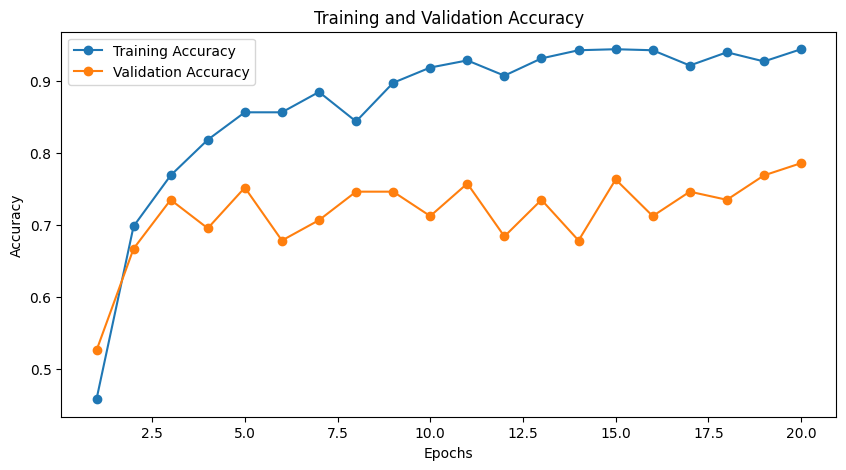

In [25]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
model.save('mobilenetv2_2.h5')

# EfficientNetB0

In [27]:
from tensorflow.keras.applications import EfficientNetB0

In [28]:
train_data = tf.keras.utils.image_dataset_from_directory(
    data,
    validation_split=0.2,
    subset="training",
    image_size=(imagewidth, imageheight),
    batch_size=batchsize,
    seed=seed
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [29]:
validationdata = tf.keras.utils.image_dataset_from_directory(
    data,
    validation_split=0.2,
    subset="validation",
    image_size=(imagewidth, imageheight),
    batch_size=batchsize,
    seed=seed
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [30]:
class_names = train_data.class_names
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Class Names: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
Number of Classes: 6


In [31]:
class_counts = {}
total_images = 0
for class_name in class_names:
  class_path = os.path.join(data, class_name)
  count = len(os.listdir(class_path))
  class_counts[class_name] = count
  total_images += count

In [32]:
class_weights = {}

for index, class_name in enumerate(class_names):
  class_weights[index] = total_images / (num_classes * class_counts[class_name])

print(class_weights)

{0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}


In [33]:
data_augmentation = tf.keras.Sequential()
data_augmentation.add(tf.keras.layers.RandomFlip("horizontal"))
data_augmentation.add(tf.keras.layers.RandomRotation(0.1))
data_augmentation.add(tf.keras.layers.RandomZoom(0.1))

In [34]:
train_images = []
train_labels = []

In [35]:
for images, labels in train_data:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

In [36]:
train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)

In [37]:
validation_images = []
validation_labels = []

In [38]:
for images, labels in validationdata:
  images = preprocess_input(images)
  validation_images.append(images)
  validation_labels.append(labels)

In [39]:
validation_images = tf.concat(validation_images, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [40]:
best_model = tf.keras.applications.EfficientNetB0(
    input_shape=(imagewidth, imageheight, 3),
    include_top=False,
    weights='imagenet'
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Ensure base_model (now best_model for EfficientNetB0) is not trainable initially
best_model.trainable = False

model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(imagewidth, imageheight, 3)), # Explicitly define input shape
    data_augmentation, # Apply data augmentation
    tf.keras.layers.Lambda(preprocess_input),  # Wrap preprocess_input in a Lambda layer
    best_model,        # Use the pre-trained EfficientNetB0 model
    tf.keras.layers.GlobalAveragePooling2D(), # Pooling layer
    tf.keras.layers.Dense(128, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(num_classes, activation='softmax') # Output layer
])

In [42]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [43]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [44]:
history = model.fit(
    train_data,
    validation_data=validationdata,
    epochs=15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 699ms/step - accuracy: 0.2401 - loss: 1.7649 - val_accuracy: 0.1921 - val_loss: 1.7910
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 586ms/step - accuracy: 0.2260 - loss: 1.7427 - val_accuracy: 0.1921 - val_loss: 1.7627
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 621ms/step - accuracy: 0.2331 - loss: 1.7413 - val_accuracy: 0.1921 - val_loss: 1.7717
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 626ms/step - accuracy: 0.2500 - loss: 1.7420 - val_accuracy: 0.2090 - val_loss: 1.7424
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 618ms/step - accuracy: 0.2260 - loss: 1.7298 - val_accuracy: 0.2260 - val_loss: 1.7285
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 572ms/step - accuracy: 0.2712 - loss: 1.7251 - val_accuracy: 0.2599 - val_loss: 1.7130
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 651ms/step - accuracy: 0.2345 - loss: 1.7298 - val_accuracy: 0.2768 - val_loss: 1.7180
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 522ms/step - accuracy: 0.2797 - loss: 1.7037 - val_accu

## Hyper Parameter Optimization

In [48]:
import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup Random Search Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,          # Same as n_iter before
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)

# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Run the search
tuner.search(
    train_data,
    validation_data=validationdata,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights  # Handles imbalance
)

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation
val_loss, val_acc = best_model.evaluate(validationdata)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 20 Complete [00h 05m 26s]
val_accuracy: 0.7344632744789124

Best val_accuracy So Far: 0.8305084705352783
Total elapsed time: 01h 25m 53s
Best hyperparameters:
{'rotation_factor': 0.25, 'zoom_factor': 0.1, 'dropout_rate': 0.1, 'dense_units': 448, 'learning_rate': 0.0043202404473434665}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 350ms/step - accuracy: 0.8305 - loss: 0.6605
Best validation accuracy: 0.8305


In [49]:
best_model.save('trained_effnet_finetune.h5')